# Tutorial: Extracting Donor Embeddings with PULSAR and Predicting Donor Age

This tutorial demonstrates how to:
1. Load a pre-trained PULSAR model
2. Extract zero-shot donor-level embeddings from single-cell data
3. Perform age prediction using donor embeddings with proper train-test split

## Overview

PULSAR is a model that aggregates single-cell embeddings to create donor-level representations. These donor embeddings can be used for various downstream tasks, including predicting donor-level phenotypes such as age. In this example, we will use PULSAR embeddings to predict **donor age** using the **OneK1K dataset** ([Yazar et al.](https://www.science.org/doi/10.1126/science.abf3041)), which contains PBMC samples from nearly 1,000 healthy donors with age annotations ranging from young adults to elderly individuals. Example data used in this tutorial can be downloaded from [here](https://drive.google.com/file/d/1HuL9uda2uIua3LphsWwt7nizgWhjFz8f/view?usp=drive_link).

## 1. Setup and Imports

First, let's import the necessary libraries and set up autoreload for development.

In [1]:
import scanpy as sc
import numpy as np
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

from pulsar.utils import extract_donor_embeddings_from_h5ad
from pulsar.model import PULSAR

%load_ext autoreload
%autoreload 2

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
""

/lfs/blackwell1/0/kuanpang/pulsar-dev/PULSAR-release-dev/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


''

## 2. Load Single-Cell Data

We'll use a subsampled **OneK1K dataset**, which contains single-cell RNA-seq data from **981 healthy donors' PBMC** samples with age annotations. The OneK1K project is a large-scale study profiling immune cell variation across a diverse population. The h5ad file has been preprocessed and includes UCE (Universal Cell Embeddings) in the `obsm` field, which capture the transcriptional state of individual cells.

Example data used in this tutorial can be downloaded from [here](https://drive.google.com/file/d/1HuL9uda2uIua3LphsWwt7nizgWhjFz8f/view?usp=drive_link).

In [2]:
# Load the h5ad file containing single-cell data + UCE embeddings
data_path = "/lfs/blackwell1/0/kuanpang/pulsar-dev/PULSAR-release-dev/benchmark_data/onek1k_raw_subsampled_uce_adata.h5ad"
adata = sc.read_h5ad(data_path)

print(f"Dataset shape: {adata.shape}")
print(f"Number of unique donors: {adata.obs['donor_id'].nunique()}")

Dataset shape: (124898, 14933)
Number of unique donors: 981


In [3]:
# Examine the data structure
adata

AnnData object with n_obs × n_vars = 124898 × 14933
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_ontology_term_id_colors', 'citation', 'default_embedding', 'schema_reference', 'schema_version', 'ti

## 3. Load Pre-trained PULSAR Model

Load the pre-trained PULSAR model from 🤗HuggingFace and prepare it for inference. We use the `pulsar-pbmc` model, which was trained on PBMC data and is well-suited for analyzing immune cell populations in the OneK1K dataset.



In [4]:
# Load the model from the huggingface model hub
pulsar_model = PULSAR.from_pretrained("KuanP/pulsar-pbmc")

# Set model to evaluation mode and move to GPU
pulsar_model.eval()
pulsar_model.cuda()

# Convert to bfloat16 for efficiency
pulsar_model = pulsar_model.to(torch.bfloat16)

print("Model loaded successfully!")

Model loaded successfully!


## 4. Extract Donor Embeddings

Use the PULSAR model to extract donor-level embeddings from the single-cell data. Each donor's embedding is computed by aggregating information from all cells belonging to that donor, capturing age-related changes in immune cell composition and gene expression patterns. The `donor_id` column in `adata.obs` is used to identify cells from the same donor. `sample_cell_num` specifies the number of cells to sample per donor for embedding extraction (1024 cells provides a robust representation of each donor's immune profile).

In [5]:
# Extract donor embeddings
donor_embedding_collection = extract_donor_embeddings_from_h5ad(
    adata,
    donor_id_key="donor_id",
    model=pulsar_model,
    sample_cell_num=1024
)

print(f"Extracted embeddings for {len(donor_embedding_collection)} donors")
# Show example of embedding structure
first_donor_id = list(donor_embedding_collection.keys())[0]
print(f"\nExample donor ID: {first_donor_id}")
print(f"Embedding shape: {donor_embedding_collection[first_donor_id]['embedding'][0].shape}")

Resample 0 time


0it [00:00, ?it/s]

99it [00:02, 47.62it/s]

Extracted embeddings for 981 donors

Example donor ID: 303_304
Embedding shape: (512,)


## 5. Prepare Data for Age Prediction

Create a mapping between donor IDs and their ages from the OneK1K dataset, then prepare the feature matrix (X) and target vector (y). We'll examine the age distribution to understand the demographic range in our dataset.

In [6]:
# Get donor_id to age mapping
donor_id_to_age = adata.obs.groupby("donor_id", observed=True)["age"].first().to_dict()

print(f"Number of donors with age information: {len(donor_id_to_age)}")
print(f"Age range: {min(donor_id_to_age.values())} - {max(donor_id_to_age.values())} years")

Number of donors with age information: 981
Age range: 19 - 97 years


In [7]:
# Prepare feature matrix (X) and target vector (y)
X = []
y = []
donor_ids = []

for donor_id, donor_data in donor_embedding_collection.items():
    embedding = donor_data["embedding"][0]  # Get the first embedding
    X.append(embedding)
    y.append(donor_id_to_age[donor_id])
    donor_ids.append(donor_id)

X = np.vstack(X)
y = np.array(y)
donor_ids = np.array(donor_ids)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (981, 512)
Target vector shape: (981,)


## 6. Train-Test Split for Age Prediction

To properly evaluate the model's ability to predict donor age from immune profiles, we'll split the donors into training and test sets. This ensures we're evaluating on held-out donors that the model hasn't seen during training, simulating real-world age prediction from new PBMC samples.

In [8]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test, donors_train, donors_test = train_test_split(
    X, y, donor_ids, test_size=0.2, random_state=0
)

print(f"Training set size: {len(X_train)} donors")
print(f"Test set size: {len(X_test)} donors")
print(f"\nTraining age range: {y_train.min():.1f} - {y_train.max():.1f} years")
print(f"Test age range: {y_test.min():.1f} - {y_test.max():.1f} years")

Training set size: 784 donors
Test set size: 197 donors

Training age range: 19.0 - 97.0 years
Test age range: 19.0 - 94.0 years


## 7. Train Ridge Regression Model

Train a Ridge regression model to predict donor age from PULSAR embeddings using only the training data. Ridge regression adds L2 regularization to prevent overfitting, which is important when working with high-dimensional embedding features.

In [15]:
# Train linear regression model on training data
reg = Ridge(alpha=0.1)
reg.fit(X_train, y_train)

print("Ridge regression model trained successfully!")

Ridge regression model trained successfully!


## 8. Evaluate Model Performance

Evaluate the model on both training and test sets to check for overfitting and assess how well the PULSAR embeddings capture age-related immune signatures in the OneK1K dataset. We report multiple regression metrics including R², Pearson correlation, MSE, and MAE.

In [16]:
# Make predictions
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

# Calculate metrics for training set
train_r2 = r2_score(y_train, y_train_pred)
train_pearson_corr, _ = pearsonr(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Calculate metrics for test set
test_r2 = r2_score(y_test, y_test_pred)
test_pearson_corr, _ = pearsonr(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
print(f"Pearson correlation: {train_pearson_corr:.4f}")
print(f"R² score: {train_r2:.4f}")
print(f"Mean Squared Error: {train_mse:.4f}")
print(f"Mean Absolute Error: {train_mae:.4f}")

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE (Held-out Donors)")
print("=" * 60)
print(f"Pearson correlation: {test_pearson_corr:.4f}")
print(f"R² score: {test_r2:.4f}")
print(f"Mean Squared Error: {test_mse:.4f}")
print(f"Mean Absolute Error: {test_mae:.4f}")


TRAINING SET PERFORMANCE
Pearson correlation: 0.8451
R² score: 0.7116
Mean Squared Error: 76.8798
Mean Absolute Error: 6.9517

TEST SET PERFORMANCE (Held-out Donors)
Pearson correlation: 0.7914
R² score: 0.6261
Mean Squared Error: 109.3114
Mean Absolute Error: 8.4559


## 9. Visualize Results

Create scatter plots to visualize the relationship between predicted and actual ages for both training and test sets. This visualization helps us understand how well the model predicts age across different age ranges in the OneK1K cohort.

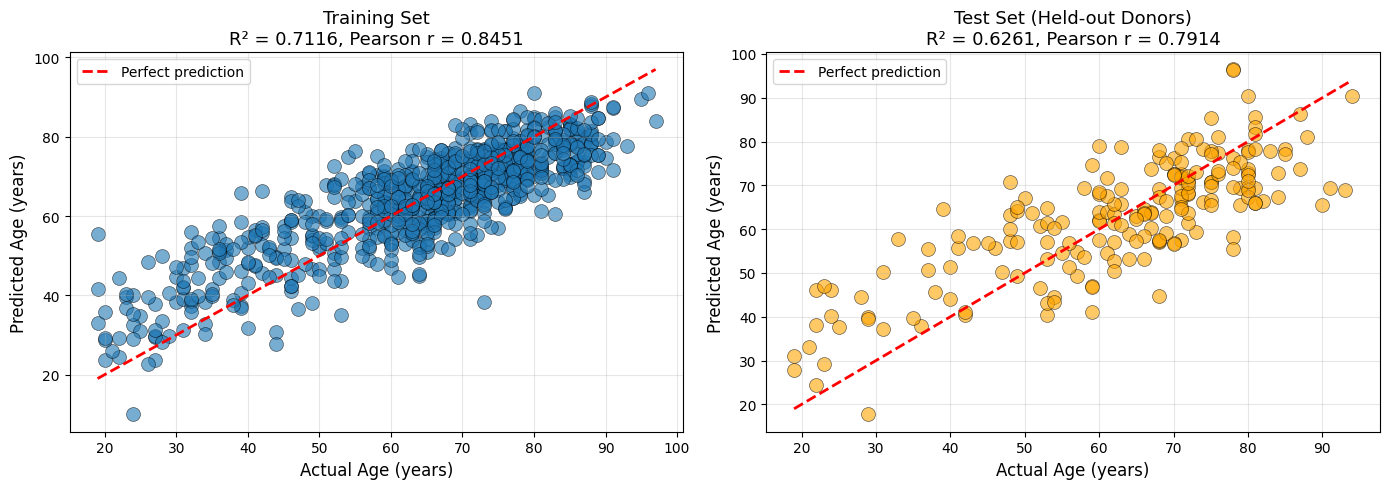

In [17]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set plot
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Age (years)', fontsize=12)
axes[0].set_ylabel('Predicted Age (years)', fontsize=12)
axes[0].set_title(f'Training Set\nR² = {train_r2:.4f}, Pearson r = {train_pearson_corr:.4f}', 
                  fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set plot
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Age (years)', fontsize=12)
axes[1].set_ylabel('Predicted Age (years)', fontsize=12)
axes[1].set_title(f'Test Set (Held-out Donors)\nR² = {test_r2:.4f}, Pearson r = {test_pearson_corr:.4f}', 
                  fontsize=13, )
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()